In [ ]:
!pip install yfinance -q

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
portfolio = pd.DataFrame({
    "ticker": [
        "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "JPM", "JNJ", "XOM", "COST", "PG", "V", "KO",
        "EME", "FIX", "DECK", "DUOL", "CAVA", "ALAB",
        "RDW", "CLSK", "LMB", "DFIN", "HIMS", "PRM",
        "SPY", "QQQ", "AGG", "TLT", "IEF", "GLD"
    ],
    "category": [
        "Large Cap", "Large Cap", "Large Cap", "Large Cap", "Large Cap", "Large Cap", "Large Cap", "Large Cap", "Large Cap", "Large Cap", "Large Cap", "Large Cap",
        "Mid Cap", "Mid Cap", "Mid Cap", "Mid Cap", "Mid Cap", "Mid Cap",
        "Small Cap", "Small Cap", "Small Cap", "Small Cap", "Small Cap", "Small Cap",
        "ETF", "ETF", "Bond ETF", "Bond ETF", "Bond ETF", "Commodity"
    ],
    "sector": [
        "Technology", "Technology", "Technology", "Consumer Discretionary", "Communication Services", "Financials", "Healthcare", "Energy", "Consumer Staples", "Consumer Staples", "Financials", "Consumer Staples",
        "Industrials", "Industrials", "Consumer Discretionary", "Communication Services", "Consumer Discretionary", "Technology",
        "Industrials", "Technology", "Industrials", "Financials", "Healthcare", "Materials",
        "Broad Market", "Technology ETF", "Fixed Income", "Fixed Income", "Fixed Income", "Commodity"
    ],
    "weight": [
        0.070, 0.070, 0.060, 0.050, 0.050, 0.040, 0.035, 0.035, 0.030, 0.030, 0.030, 0.025,
        0.025, 0.025, 0.020, 0.020, 0.020, 0.020,
        0.015, 0.015, 0.015, 0.015, 0.015, 0.015,
        0.030, 0.060, 0.050, 0.040, 0.035, 0.040
    ]
})

print(f"Total Portfolio Weight: {portfolio['weight'].sum():.1%}")

assert np.isclose(portfolio["weight"].sum(), 1.0), "Portfolio weights must sum to 100%."

portfolio

Total Portfolio Weight: 100.0%


,ticker,category,sector,weight
0,AAPL,Large Cap,Technology,0.070
1,MSFT,Large Cap,Technology,0.070
2,NVDA,Large Cap,Technology,0.060
3,AMZN,Large Cap,Consumer Discretionary,0.050
4,GOOGL,Large Cap,Communication Services,0.050
5,JPM,Large Cap,Financials,0.040
6,JNJ,Large Cap,Healthcare,0.035
7,XOM,Large Cap,Energy,0.035
8,COST,Large Cap,Consumer Staples,0.030
9,PG,Large Cap,Consumer Staples,0.030


## Download Historical Price Data

This section pulls adjusted daily closing prices for all portfolio holdings using Yahoo Finance. The data begins after all selected holdings had publicly traded price history available.

In [ ]:
# Download historical price data

start_date = "2024-03-20"
end_date = "2026-01-01"

tickers = portfolio["ticker"].tolist()

prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"]

prices.head()

Ticker,AAPL,AGG,ALAB,AMZN,CAVA,CLSK,COST,DECK,DFIN,DUOL,...,MSFT,NVDA,PG,PRM,QQQ,RDW,SPY,TLT,V,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-03-20,176.895645,89.349464,62.029999,178.149994,68.320000,20.250000,731.610657,152.529999,62.169998,234.000000,...,417.896851,90.215897,152.716873,6.35,438.467438,3.92,506.808319,84.371651,284.415161,104.957535
2024-03-21,169.668121,89.413651,64.150002,178.149994,67.820000,20.770000,733.428101,158.823334,62.230000,235.619995,...,421.965393,91.277039,152.594315,6.30,440.542358,4.24,508.483246,84.553314,285.486847,105.421989
2024-03-22,170.569077,89.697914,70.000000,178.869995,67.959999,19.520000,725.763550,153.740005,61.259998,232.089996,...,421.346252,94.126122,152.405777,6.22,441.046234,4.48,507.519165,85.361710,278.496429,105.421989
2024-03-25,169.153290,89.532852,85.000000,179.710007,68.250000,23.400000,721.970825,155.431671,60.509998,226.500000,...,415.567657,94.837883,151.019897,7.21,439.445618,4.48,506.117096,84.934807,276.480896,106.499527
2024-03-26,168.024628,89.624542,83.379997,178.300003,68.220001,23.190001,721.990540,156.241669,60.630001,223.440002,...,414.378510,92.401100,151.359329,7.33,438.022827,4.25,505.182251,85.170937,275.881165,105.700645


## Calculate Daily Returns

Daily returns are calculated from adjusted closing prices and are used to compute portfolio-level performance and risk metrics.

In [ ]:
# Calculate daily returns for each holding

daily_returns = prices.pct_change().dropna()

daily_returns.head()

Ticker,AAPL,AGG,ALAB,AMZN,CAVA,CLSK,COST,DECK,DFIN,DUOL,...,MSFT,NVDA,PG,PRM,QQQ,RDW,SPY,TLT,V,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-03-21,-0.040858,0.000718,0.034177,0.000000,-0.007319,0.025679,0.002484,0.041260,0.000965,0.006923,...,0.009736,0.011762,-0.000803,-0.007874,0.004732,0.081633,0.003305,0.002153,0.003768,0.004425
2024-03-22,0.005310,0.003179,0.091192,0.004042,0.002064,-0.060183,-0.010450,-0.032006,-0.015587,-0.014982,...,-0.001467,0.031214,-0.001236,-0.012698,0.001144,0.056604,-0.001896,0.009561,-0.024486,0.000000
2024-03-25,-0.008300,-0.001840,0.214286,0.004696,0.004267,0.198770,-0.005226,0.011003,-0.012243,-0.024085,...,-0.013715,0.007562,-0.009093,0.159164,-0.003629,0.000000,-0.002763,-0.005001,-0.007237,0.010221
2024-03-26,-0.006672,0.001024,-0.019059,-0.007846,-0.000440,-0.008974,0.000027,0.005211,0.001983,-0.013510,...,-0.002862,-0.025694,0.002248,0.016644,-0.003238,-0.051339,-0.001847,0.002780,-0.002169,-0.007501
2024-03-27,0.021213,0.003274,-0.041497,0.008581,0.013925,-0.003450,0.001505,0.000480,0.006103,-0.003983,...,-0.000522,-0.024967,0.012831,0.000000,0.003406,0.037647,0.008404,0.009918,-0.005631,0.010370


In [ ]:
# Match portfolio weights to the order of return columns

weights = portfolio.set_index("ticker").loc[daily_returns.columns, "weight"]

# Calculate daily portfolio returns

portfolio_returns = daily_returns.dot(weights)

portfolio_returns.head()

,0
Date,
2024-03-21,0.004365
2024-03-22,0.001782
2024-03-25,0.006403
2024-03-26,-0.003562
2024-03-27,0.003623


In [ ]:
print(f"Number of trading days analyzed: {len(portfolio_returns)}")
print(f"Average daily portfolio return: {portfolio_returns.mean():.4%}")

Number of trading days analyzed: 447
Average daily portfolio return: 0.1039%


## Portfolio Performance and Risk Metrics

This section calculates key portfolio analytics, including total return, annualized return, volatility, Sharpe ratio, and maximum drawdown. These metrics help evaluate both performance and risk.

In [ ]:
# Portfolio performance and risk metrics

trading_days = 252
risk_free_rate = 0.04

total_return = (1 + portfolio_returns).prod() - 1

annualized_return = (1 + total_return) ** (trading_days / len(portfolio_returns)) - 1

annualized_volatility = portfolio_returns.std() * np.sqrt(trading_days)

sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

cumulative_returns = (1 + portfolio_returns).cumprod()

running_max = cumulative_returns.cummax()

drawdown = (cumulative_returns / running_max) - 1

max_drawdown = drawdown.min()

summary_metrics = pd.DataFrame({
    "Metric": [
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    "Value": [
        f"{total_return:.2%}",
        f"{annualized_return:.2%}",
        f"{annualized_volatility:.2%}",
        f"{sharpe_ratio:.2f}",
        f"{max_drawdown:.2%}"
    ]
})

summary_metrics

,Metric,Value
0,Total Return,54.80%
1,Annualized Return,27.93%
2,Annualized Volatility,17.57%
3,Sharpe Ratio,1.36
4,Maximum Drawdown,-19.24%


## Growth of $1 Invested

This chart shows how one dollar invested in the portfolio would have grown over the analysis period.

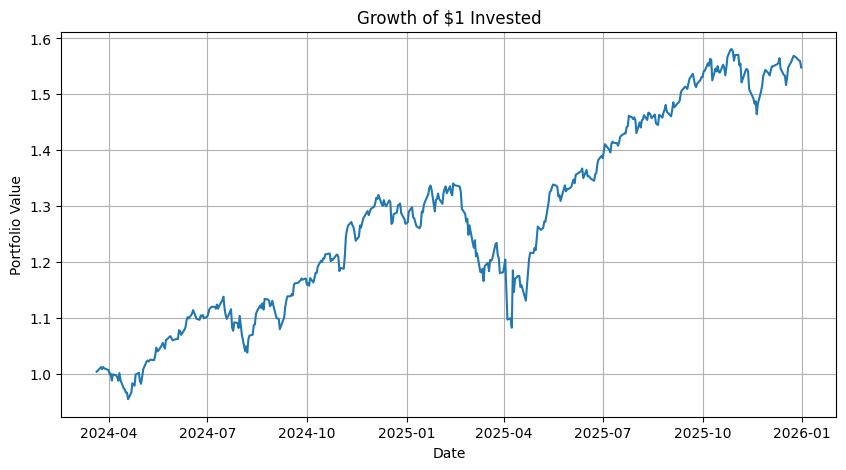

In [ ]:
# Plot growth of $1 invested

plt.figure(figsize=(10, 5))
plt.plot(cumulative_returns)
plt.title("Growth of $1 Invested")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

## Portfolio Drawdown

This chart shows the portfolio's decline from previous peaks over time. Maximum drawdown is one of the most important risk metrics because it measures the worst peak-to-trough loss.

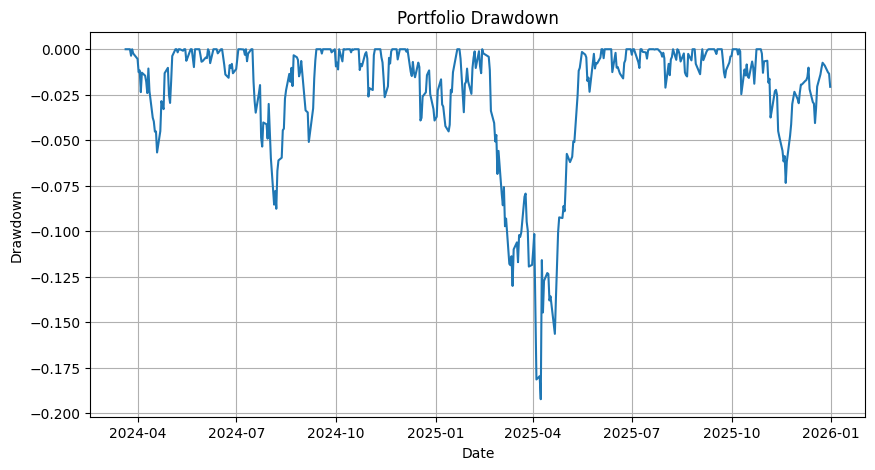

In [ ]:
# Plot portfolio drawdown

plt.figure(figsize=(10, 5))
plt.plot(drawdown)
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

## Portfolio Allocation Analysis

This section analyzes how the portfolio is allocated across sectors, market capitalization groups, and asset classes. Allocation analysis helps identify concentration risk and diversification across the portfolio.

In [ ]:
# Sector allocation

sector_allocation = (
    portfolio
    .groupby("sector")["weight"]
    .sum()
    .sort_values(ascending=False)
)

sector_allocation

,weight
sector,
Technology,0.235
Fixed Income,0.125
Consumer Discretionary,0.090
Consumer Staples,0.085
Financials,0.085
Industrials,0.080
Communication Services,0.070
Technology ETF,0.060
Healthcare,0.050


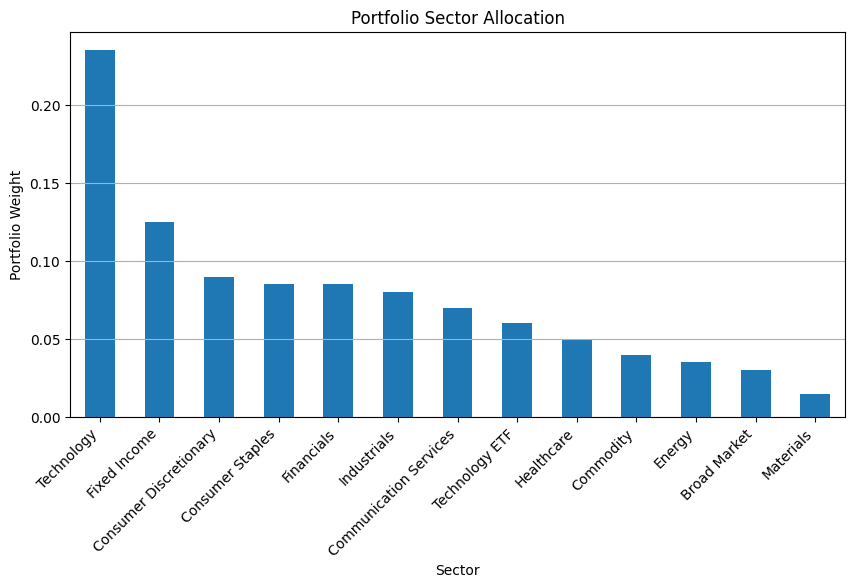

In [ ]:
plt.figure(figsize=(10, 5))
sector_allocation.plot(kind="bar")
plt.title("Portfolio Sector Allocation")
plt.xlabel("Sector")
plt.ylabel("Portfolio Weight")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

In [ ]:
# Market cap allocation

category_allocation = (
    portfolio
    .groupby("category")["weight"]
    .sum()
    .sort_values(ascending=False)
)

category_allocation

,weight
category,
Large Cap,0.525
Mid Cap,0.130
Bond ETF,0.125
ETF,0.090
Small Cap,0.090
Commodity,0.040


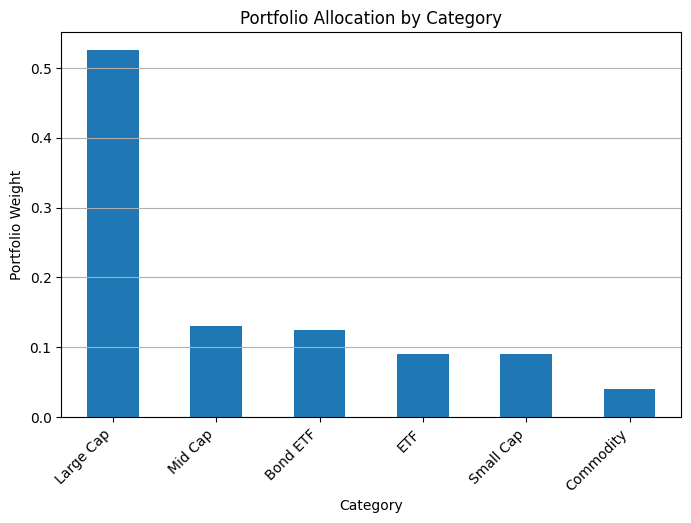

In [ ]:
plt.figure(figsize=(8, 5))
category_allocation.plot(kind="bar")
plt.title("Portfolio Allocation by Category")
plt.xlabel("Category")
plt.ylabel("Portfolio Weight")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

## Top and Bottom Performing Holdings

This section calculates each holding's total return over the analysis period and ranks the best and worst performers. This helps identify which securities contributed positively or negatively to portfolio performance.

In [ ]:
# Calculate total return for each holding

holding_returns = (prices.iloc[-1] / prices.iloc[0]) - 1

holding_performance = pd.DataFrame({
    "Ticker": holding_returns.index,
    "Total Return": holding_returns.values
})

holding_performance = holding_performance.merge(
    portfolio[["ticker", "category", "sector", "weight"]],
    left_on="Ticker",
    right_on="ticker",
    how="left"
).drop(columns="ticker")

holding_performance["Weighted Contribution"] = (
    holding_performance["Total Return"] * holding_performance["weight"]
)

holding_performance = holding_performance.sort_values(
    "Total Return",
    ascending=False
)

holding_performance.head()

In [42]:
top_10_performers = holding_performance.head(10)

top_10_performers.style.format({
    "Total Return": "{:.2%}",
    "weight": "{:.2%}",
    "Weighted Contribution": "{:.2%}"
})

,Ticker,Total Return,category,sector,weight,Weighted Contribution
23,PRM,333.54%,Small Cap,Materials,1.50%,5.00%
11,FIX,198.76%,Mid Cap,Industrials,2.50%,4.97%
2,ALAB,168.19%,Mid Cap,Technology,2.00%,3.36%
13,GOOGL,112.02%,Large Cap,Communication Services,5.00%,5.60%
21,NVDA,106.47%,Large Cap,Technology,6.00%,6.39%
14,HIMS,97.03%,Small Cap,Healthcare,1.50%,1.46%
12,GLD,96.02%,Commodity,Commodity,4.00%,3.84%
25,RDW,93.88%,Small Cap,Industrials,1.50%,1.41%
10,EME,83.82%,Mid Cap,Industrials,2.50%,2.10%
19,LMB,77.17%,Small Cap,Industrials,1.50%,1.16%


In [43]:
bottom_10_performers = holding_performance.tail(10)

bottom_10_performers.style.format({
    "Total Return": "{:.2%}",
    "weight": "{:.2%}",
    "Weighted Contribution": "{:.2%}"
})

,Ticker,Total Return,category,sector,weight,Weighted Contribution
29,XOM,13.13%,Large Cap,Energy,3.50%,0.46%
1,AGG,9.96%,Bond ETF,Fixed Income,5.00%,0.50%
15,IEF,9.48%,Bond ETF,Fixed Income,3.50%,0.33%
27,TLT,1.39%,Bond ETF,Fixed Income,4.00%,0.06%
22,PG,-7.52%,Large Cap,Consumer Staples,3.00%,-0.23%
4,CAVA,-14.10%,Mid Cap,Consumer Discretionary,2.00%,-0.28%
8,DFIN,-24.90%,Small Cap,Financials,1.50%,-0.37%
9,DUOL,-25.00%,Mid Cap,Communication Services,2.00%,-0.50%
7,DECK,-32.03%,Mid Cap,Consumer Discretionary,2.00%,-0.64%
5,CLSK,-50.02%,Small Cap,Technology,1.50%,-0.75%


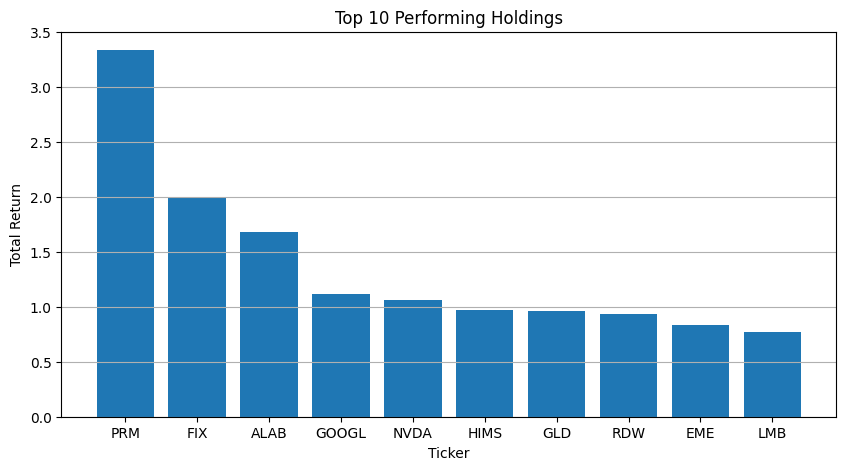

In [44]:
plt.figure(figsize=(10, 5))
plt.bar(top_10_performers["Ticker"], top_10_performers["Total Return"])
plt.title("Top 10 Performing Holdings")
plt.xlabel("Ticker")
plt.ylabel("Total Return")
plt.grid(axis="y")
plt.show()

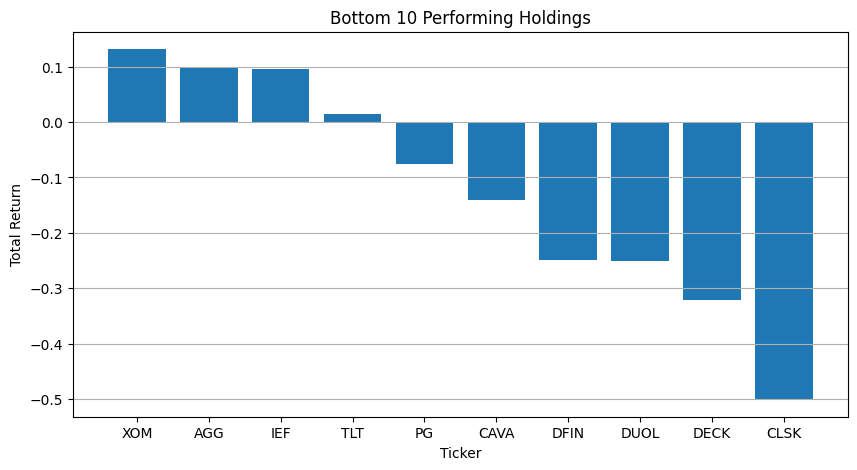

In [45]:
plt.figure(figsize=(10, 5))
plt.bar(bottom_10_performers["Ticker"], bottom_10_performers["Total Return"])
plt.title("Bottom 10 Performing Holdings")
plt.xlabel("Ticker")
plt.ylabel("Total Return")
plt.grid(axis="y")
plt.show()

## Performance Contribution

This section estimates each holding's contribution to total portfolio performance by multiplying its total return by its portfolio weight. This helps identify which positions had the greatest impact on the overall portfolio, not just which had the highest standalone return.

In [46]:
# Rank holdings by weighted contribution to portfolio return

contribution_analysis = holding_performance.sort_values(
    "Weighted Contribution",
    ascending=False
).copy()

contribution_analysis.style.format({
    "Total Return": "{:.2%}",
    "weight": "{:.2%}",
    "Weighted Contribution": "{:.2%}"
})

,Ticker,Total Return,category,sector,weight,Weighted Contribution
21,NVDA,106.47%,Large Cap,Technology,6.00%,6.39%
13,GOOGL,112.02%,Large Cap,Communication Services,5.00%,5.60%
23,PRM,333.54%,Small Cap,Materials,1.50%,5.00%
11,FIX,198.76%,Mid Cap,Industrials,2.50%,4.97%
12,GLD,96.02%,Commodity,Commodity,4.00%,3.84%
0,AAPL,53.40%,Large Cap,Technology,7.00%,3.74%
2,ALAB,168.19%,Mid Cap,Technology,2.00%,3.36%
17,JPM,70.55%,Large Cap,Financials,4.00%,2.82%
24,QQQ,39.77%,ETF,Technology ETF,6.00%,2.39%
10,EME,83.82%,Mid Cap,Industrials,2.50%,2.10%


In [47]:
top_contributors = contribution_analysis.head(10)

top_contributors[[
    "Ticker",
    "category",
    "sector",
    "weight",
    "Total Return",
    "Weighted Contribution"
]].style.format({
    "weight": "{:.2%}",
    "Total Return": "{:.2%}",
    "Weighted Contribution": "{:.2%}"
})

,Ticker,category,sector,weight,Total Return,Weighted Contribution
21,NVDA,Large Cap,Technology,6.00%,106.47%,6.39%
13,GOOGL,Large Cap,Communication Services,5.00%,112.02%,5.60%
23,PRM,Small Cap,Materials,1.50%,333.54%,5.00%
11,FIX,Mid Cap,Industrials,2.50%,198.76%,4.97%
12,GLD,Commodity,Commodity,4.00%,96.02%,3.84%
0,AAPL,Large Cap,Technology,7.00%,53.40%,3.74%
2,ALAB,Mid Cap,Technology,2.00%,168.19%,3.36%
17,JPM,Large Cap,Financials,4.00%,70.55%,2.82%
24,QQQ,ETF,Technology ETF,6.00%,39.77%,2.39%
10,EME,Mid Cap,Industrials,2.50%,83.82%,2.10%


In [48]:
bottom_contributors = contribution_analysis.tail(10)

bottom_contributors[[
    "Ticker",
    "category",
    "sector",
    "weight",
    "Total Return",
    "Weighted Contribution"
]].style.format({
    "weight": "{:.2%}",
    "Total Return": "{:.2%}",
    "Weighted Contribution": "{:.2%}"
})

,Ticker,category,sector,weight,Total Return,Weighted Contribution
1,AGG,Bond ETF,Fixed Income,5.00%,9.96%,0.50%
29,XOM,Large Cap,Energy,3.50%,13.13%,0.46%
15,IEF,Bond ETF,Fixed Income,3.50%,9.48%,0.33%
27,TLT,Bond ETF,Fixed Income,4.00%,1.39%,0.06%
22,PG,Large Cap,Consumer Staples,3.00%,-7.52%,-0.23%
4,CAVA,Mid Cap,Consumer Discretionary,2.00%,-14.10%,-0.28%
8,DFIN,Small Cap,Financials,1.50%,-24.90%,-0.37%
9,DUOL,Mid Cap,Communication Services,2.00%,-25.00%,-0.50%
7,DECK,Mid Cap,Consumer Discretionary,2.00%,-32.03%,-0.64%
5,CLSK,Small Cap,Technology,1.50%,-50.02%,-0.75%


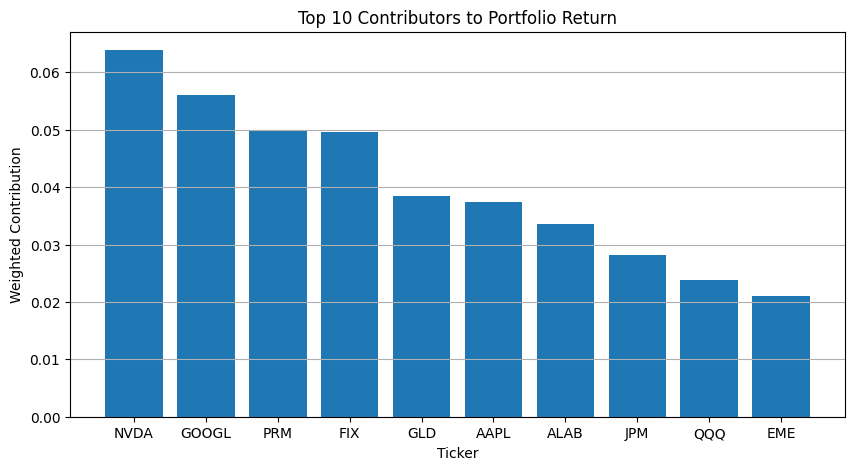

In [49]:
plt.figure(figsize=(10, 5))
plt.bar(top_contributors["Ticker"], top_contributors["Weighted Contribution"])
plt.title("Top 10 Contributors to Portfolio Return")
plt.xlabel("Ticker")
plt.ylabel("Weighted Contribution")
plt.grid(axis="y")
plt.show()

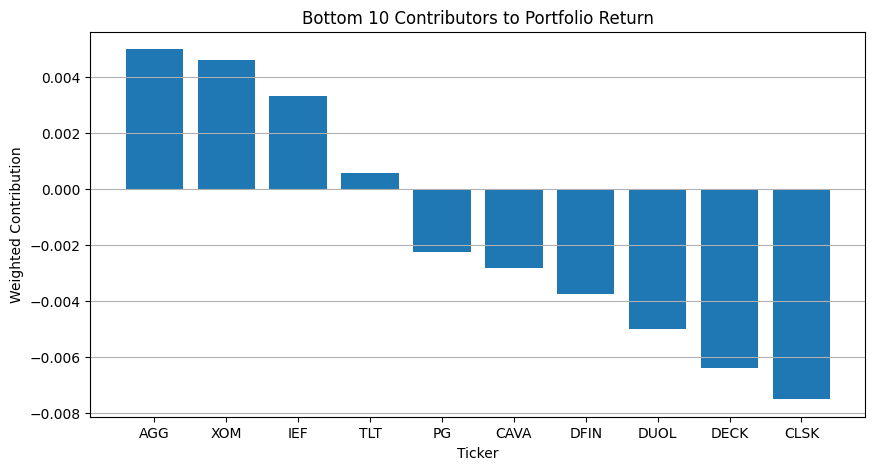

In [50]:
plt.figure(figsize=(10, 5))
plt.bar(bottom_contributors["Ticker"], bottom_contributors["Weighted Contribution"])
plt.title("Bottom 10 Contributors to Portfolio Return")
plt.xlabel("Ticker")
plt.ylabel("Weighted Contribution")
plt.grid(axis="y")
plt.show()

## Correlation Analysis

This section analyzes how portfolio holdings move relative to one another. A correlation matrix helps evaluate diversification by showing whether holdings tend to move together or independently.

In [51]:
# Correlation matrix

correlation_matrix = daily_returns.corr()

correlation_matrix

Ticker,AAPL,AGG,ALAB,AMZN,CAVA,CLSK,COST,DECK,DFIN,DUOL,...,MSFT,NVDA,PG,PRM,QQQ,RDW,SPY,TLT,V,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.135646,0.242820,0.496227,0.328460,0.251860,0.385268,0.311344,0.281869,0.244118,...,0.481460,0.373147,0.150159,0.218710,0.674597,0.144296,0.693405,0.102376,0.387330,0.252892
AGG,0.135646,1.000000,-0.019127,-0.050800,0.011822,-0.007876,0.117441,0.076508,0.162317,-0.052456,...,0.015480,-0.050896,0.245669,-0.029411,0.060340,0.046392,0.110378,0.940894,0.147055,-0.016093
ALAB,0.242820,-0.019127,1.000000,0.406174,0.299926,0.290595,0.160503,0.245383,0.133948,0.324771,...,0.331323,0.492057,-0.141716,0.184949,0.519111,0.237850,0.459488,-0.020361,0.128278,0.102471
AMZN,0.496227,-0.050800,0.406174,1.000000,0.383697,0.336204,0.301372,0.347304,0.268218,0.333477,...,0.611283,0.499917,-0.055288,0.219822,0.750493,0.296599,0.726662,-0.072958,0.335869,0.153340
CAVA,0.328460,0.011822,0.299926,0.383697,1.000000,0.281667,0.322084,0.336889,0.258204,0.375433,...,0.343354,0.441652,-0.007969,0.180439,0.525579,0.316783,0.525212,-0.012311,0.269671,0.144493
CLSK,0.251860,-0.007876,0.290595,0.336204,0.281667,1.000000,0.172512,0.250139,0.296847,0.243807,...,0.306152,0.321176,-0.058838,0.250065,0.470181,0.314432,0.462962,-0.024956,0.236763,0.113931
COST,0.385268,0.117441,0.160503,0.301372,0.322084,0.172512,1.000000,0.213018,0.214074,0.240446,...,0.354202,0.217832,0.297754,0.134506,0.448141,0.147292,0.461100,0.093116,0.425819,0.066455
DECK,0.311344,0.076508,0.245383,0.347304,0.336889,0.250139,0.213018,1.000000,0.340556,0.267422,...,0.313094,0.305456,0.017890,0.216550,0.446019,0.254196,0.474636,0.078525,0.286636,0.148352
DFIN,0.281869,0.162317,0.133948,0.268218,0.258204,0.296847,0.214074,0.340556,1.000000,0.222815,...,0.243115,0.176228,0.092875,0.268195,0.379591,0.262334,0.438402,0.118263,0.349561,0.190396


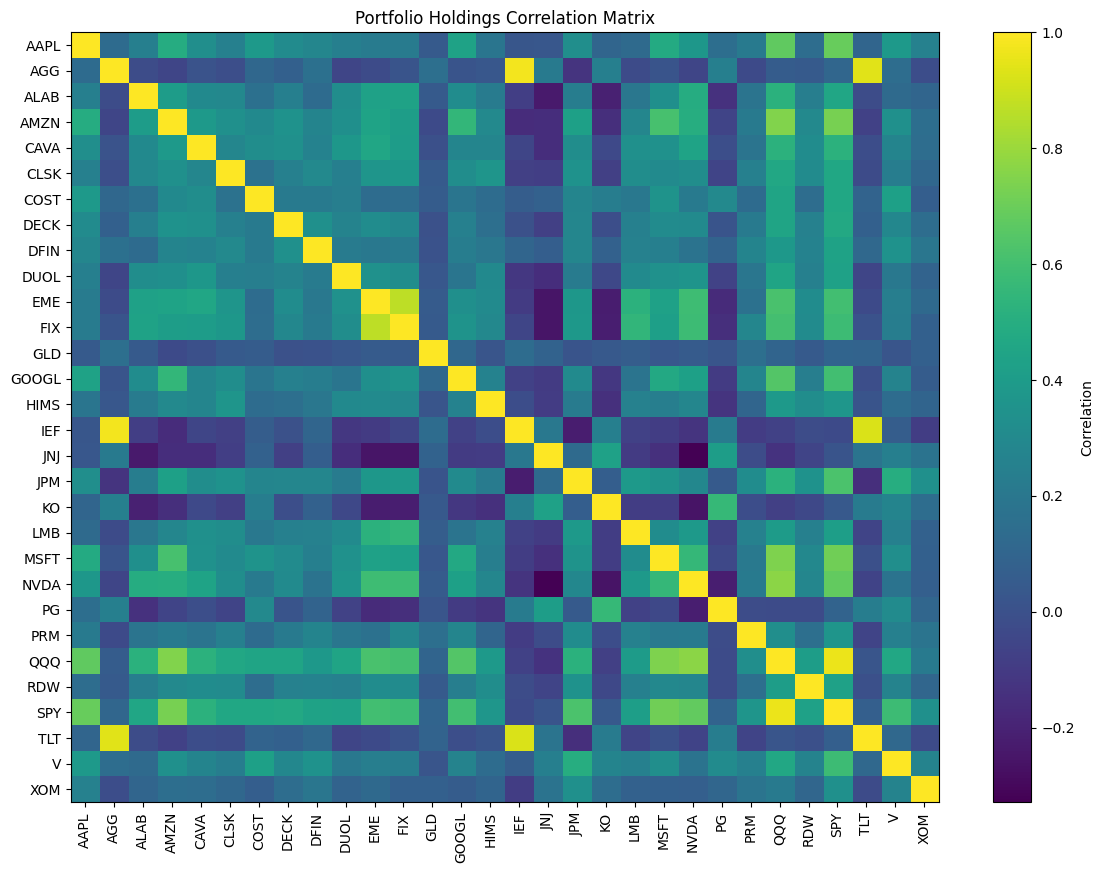

In [52]:
plt.figure(figsize=(14, 10))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Portfolio Holdings Correlation Matrix")
plt.show()

## Rolling Volatility

This section calculates 30-day rolling volatility to show how portfolio risk changed over time.

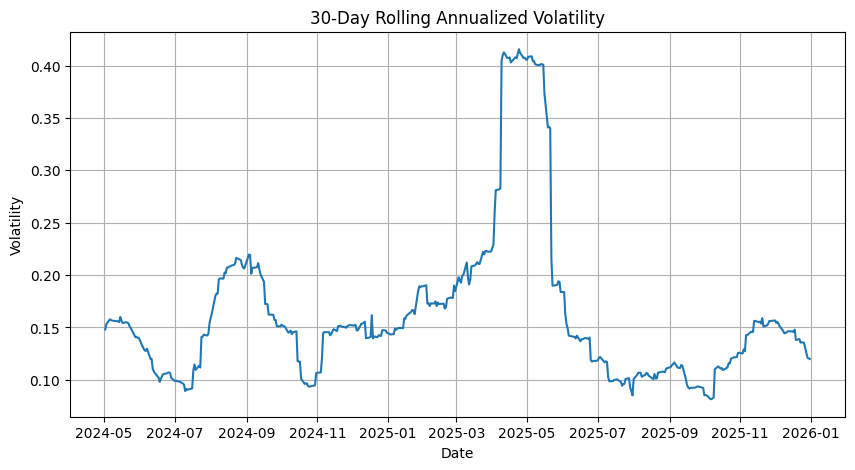

In [53]:
# 30-day rolling annualized volatility

rolling_volatility = portfolio_returns.rolling(window=30).std() * np.sqrt(252)

plt.figure(figsize=(10, 5))
plt.plot(rolling_volatility)
plt.title("30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

## Portfolio Summary Dashboard

This final summary combines the key portfolio metrics into a single view.

In [56]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

def show_kpi_dashboard():
    top_contributor = top_contributors.iloc[0]["Ticker"]
    bottom_contributor = bottom_contributors.iloc[0]["Ticker"]

    dashboard_html = f"""
    <div style="font-family: Arial, sans-serif; padding: 20px; border-radius: 12px; background-color: #f7f9fc;">
        <h2 style="text-align:center; color:#1f2937;">Institutional Portfolio Risk & Performance Dashboard</h2>
        <p style="text-align:center; color:#4b5563;">
            Interactive summary of portfolio performance, risk, diversification, and contribution metrics
        </p>

        <div style="display:grid; grid-template-columns: repeat(3, 1fr); gap:15px; margin-top:25px;">
            <div style="background:white; padding:18px; border-radius:10px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
                <h4 style="color:#6b7280;">Total Return</h4>
                <h2 style="color:#111827;">{total_return:.2%}</h2>
            </div>

            <div style="background:white; padding:18px; border-radius:10px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
                <h4 style="color:#6b7280;">Annualized Return</h4>
                <h2 style="color:#111827;">{annualized_return:.2%}</h2>
            </div>

            <div style="background:white; padding:18px; border-radius:10px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
                <h4 style="color:#6b7280;">Annualized Volatility</h4>
                <h2 style="color:#111827;">{annualized_volatility:.2%}</h2>
            </div>

            <div style="background:white; padding:18px; border-radius:10px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
                <h4 style="color:#6b7280;">Sharpe Ratio</h4>
                <h2 style="color:#111827;">{sharpe_ratio:.2f}</h2>
            </div>

            <div style="background:white; padding:18px; border-radius:10px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
                <h4 style="color:#6b7280;">Maximum Drawdown</h4>
                <h2 style="color:#b91c1c;">{max_drawdown:.2%}</h2>
            </div>

            <div style="background:white; padding:18px; border-radius:10px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
                <h4 style="color:#6b7280;">Holdings</h4>
                <h2 style="color:#111827;">{len(portfolio)}</h2>
            </div>

            <div style="background:white; padding:18px; border-radius:10px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
                <h4 style="color:#6b7280;">Sectors</h4>
                <h2 style="color:#111827;">{portfolio["sector"].nunique()}</h2>
            </div>

            <div style="background:white; padding:18px; border-radius:10px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
                <h4 style="color:#6b7280;">Top Contributor</h4>
                <h2 style="color:#047857;">{top_contributor}</h2>
            </div>

            <div style="background:white; padding:18px; border-radius:10px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
                <h4 style="color:#6b7280;">Bottom Contributor</h4>
                <h2 style="color:#b91c1c;">{bottom_contributor}</h2>
            </div>
        </div>
    </div>
    """

    display(HTML(dashboard_html))


def show_top_contributors():
    display(
        top_contributors[["Ticker", "category", "sector", "weight", "Total Return", "Weighted Contribution"]]
        .style.format({
            "weight": "{:.2%}",
            "Total Return": "{:.2%}",
            "Weighted Contribution": "{:.2%}"
        })
    )


def show_bottom_contributors():
    display(
        bottom_contributors[["Ticker", "category", "sector", "weight", "Total Return", "Weighted Contribution"]]
        .style.format({
            "weight": "{:.2%}",
            "Total Return": "{:.2%}",
            "Weighted Contribution": "{:.2%}"
        })
    )


def show_sector_allocation():
    plt.figure(figsize=(10, 5))
    sector_allocation.plot(kind="bar")
    plt.title("Portfolio Sector Allocation")
    plt.xlabel("Sector")
    plt.ylabel("Portfolio Weight")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.show()


def show_category_allocation():
    plt.figure(figsize=(8, 5))
    category_allocation.plot(kind="bar")
    plt.title("Portfolio Allocation by Category")
    plt.xlabel("Category")
    plt.ylabel("Portfolio Weight")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.show()


def show_drawdown():
    plt.figure(figsize=(10, 5))
    plt.plot(drawdown)
    plt.title("Portfolio Drawdown")
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.grid(True)
    plt.show()


def show_rolling_volatility():
    rolling_volatility = portfolio_returns.rolling(window=30).std() * np.sqrt(252)

    plt.figure(figsize=(10, 5))
    plt.plot(rolling_volatility)
    plt.title("30-Day Rolling Annualized Volatility")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.grid(True)
    plt.show()


def show_growth():
    plt.figure(figsize=(10, 5))
    plt.plot(cumulative_returns)
    plt.title("Growth of $1 Invested")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.grid(True)
    plt.show()


dashboard_selector = widgets.Dropdown(
    options=[
        "KPI Dashboard",
        "Growth of $1",
        "Drawdown",
        "Rolling Volatility",
        "Sector Allocation",
        "Category Allocation",
        "Top Contributors",
        "Bottom Contributors"
    ],
    value="KPI Dashboard",
    description="View:",
    style={"description_width": "initial"}
)

output = widgets.Output()

def update_dashboard(change):
    with output:
        clear_output(wait=True)

        if change["new"] == "KPI Dashboard":
            show_kpi_dashboard()
        elif change["new"] == "Growth of $1":
            show_growth()
        elif change["new"] == "Drawdown":
            show_drawdown()
        elif change["new"] == "Rolling Volatility":
            show_rolling_volatility()
        elif change["new"] == "Sector Allocation":
            show_sector_allocation()
        elif change["new"] == "Category Allocation":
            show_category_allocation()
        elif change["new"] == "Top Contributors":
            show_top_contributors()
        elif change["new"] == "Bottom Contributors":
            show_bottom_contributors()

dashboard_selector.observe(update_dashboard, names="value")

display(dashboard_selector, output)

with output:
    show_kpi_dashboard()

Dropdown(description='View:', options=('KPI Dashboard', 'Growth of $1', 'Drawdown', 'Rolling Volatility', 'Sec…

Output()

## Interactive Portfolio Dashboard

This interactive dashboard allows users to explore portfolio performance, risk, allocation, and contribution analysis from one interface.